# 06 LSTM Next-Hour Forecasting Benchmark

Evaluate an LSTM as a separate time-series experiment. For each selected building, the previous 24 hourly observations are used to predict the next hour's electricity consumption.

The LSTM is compared with a persistence baseline that predicts the next reading will equal the most recent observed reading. Its results should not be placed directly in the tabular-model table because the prediction paradigm and input history differ.

## Setup

In [1]:
import os
from pathlib import Path
from time import perf_counter

# Required by the installed TensorFlow and Protobuf combination.
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM

RANDOM_STATE = 42
SEQUENCE_HOURS = 24
BUILDING_LIMIT = 50
BATCH_SIZE = 256
MAX_EPOCHS = 20

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Load a Reproducible Building Subset

In [2]:
sequence_columns = [
    "building_id",
    "timestamp",
    "meter_reading",
    "site_id",
    "primary_use",
    "square_feet",
    "year_built",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

train_data = pd.read_parquet(
    modeling_dir / "model_train.parquet",
    columns=sequence_columns,
)
validation_data = pd.read_parquet(
    modeling_dir / "model_validation.parquet",
    columns=sequence_columns,
)
test_data = pd.read_parquet(
    modeling_dir / "model_test.parquet",
    columns=sequence_columns,
)

common_buildings = sorted(
    set(train_data["building_id"])
    & set(validation_data["building_id"])
    & set(test_data["building_id"])
)
random_generator = np.random.default_rng(RANDOM_STATE)
selected_buildings = np.sort(
    random_generator.choice(
        common_buildings,
        size=min(BUILDING_LIMIT, len(common_buildings)),
        replace=False,
    )
)

train_data = train_data[train_data["building_id"].isin(selected_buildings)].copy()
validation_data = validation_data[
    validation_data["building_id"].isin(selected_buildings)
].copy()
test_data = test_data[test_data["building_id"].isin(selected_buildings)].copy()

pd.Series(
    {
        "selected_buildings": len(selected_buildings),
        "training_rows": len(train_data),
        "validation_rows": len(validation_data),
        "test_rows": len(test_data),
    }
)

selected_buildings        50
training_rows         300656
validation_rows        65871
test_rows              65364
dtype: int64

## Fit Training-Only Preprocessing

In [3]:
def add_sequence_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["log_square_feet"] = np.log1p(result["square_feet"])
    result["building_age"] = (2016 - result["year_built"]).clip(lower=0)
    return result.sort_values(["building_id", "timestamp"]).reset_index(drop=True)


train_data = add_sequence_features(train_data)
validation_data = add_sequence_features(validation_data)
test_data = add_sequence_features(test_data)

numeric_sequence_features = [
    "meter_reading",
    "log_square_feet",
    "building_age",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
categorical_sequence_features = ["site_id", "primary_use"]
sequence_feature_columns = (
    numeric_sequence_features + categorical_sequence_features
)

sequence_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_sequence_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            categorical_sequence_features,
        ),
    ]
)
target_scaler = StandardScaler()

train_features = sequence_preprocessor.fit_transform(
    train_data[sequence_feature_columns]
).astype("float32")
validation_features = sequence_preprocessor.transform(
    validation_data[sequence_feature_columns]
).astype("float32")
test_features = sequence_preprocessor.transform(
    test_data[sequence_feature_columns]
).astype("float32")

train_target = target_scaler.fit_transform(
    train_data[["meter_reading"]]
).ravel().astype("float32")
validation_target = target_scaler.transform(
    validation_data[["meter_reading"]]
).ravel().astype("float32")
test_target = target_scaler.transform(
    test_data[["meter_reading"]]
).ravel().astype("float32")

train_features.shape, validation_features.shape, test_features.shape

((300656, 37), (65871, 37), (65364, 37))

## Build Gap-Safe 24-Hour Sequences

In [4]:
def build_sequence_dataset(
    frame: pd.DataFrame,
    feature_matrix: np.ndarray,
    scaled_target: np.ndarray,
    shuffle: bool,
) -> tuple[tf.data.Dataset, int]:
    combined_dataset = None
    sequence_count = 0

    for _, building_rows in frame.groupby("building_id", sort=False):
        row_positions = building_rows.index.to_numpy()
        timestamps = building_rows["timestamp"]
        segment_ids = timestamps.diff().ne(pd.Timedelta(hours=1)).cumsum()

        for _, segment_rows in building_rows.groupby(segment_ids, sort=False):
            segment_positions = segment_rows.index.to_numpy()
            if len(segment_positions) <= SEQUENCE_HOURS:
                continue

            segment_features = feature_matrix[segment_positions]
            segment_target = scaled_target[segment_positions]
            segment_dataset = tf.keras.utils.timeseries_dataset_from_array(
                data=segment_features[:-1],
                targets=segment_target[SEQUENCE_HOURS:],
                sequence_length=SEQUENCE_HOURS,
                sequence_stride=1,
                shuffle=False,
                batch_size=None,
            )
            sequence_count += len(segment_positions) - SEQUENCE_HOURS
            combined_dataset = (
                segment_dataset
                if combined_dataset is None
                else combined_dataset.concatenate(segment_dataset)
            )

    if combined_dataset is None:
        raise ValueError("No complete hourly sequences were available.")

    if shuffle:
        combined_dataset = combined_dataset.shuffle(
            buffer_size=min(sequence_count, 20_000),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )

    return (
        combined_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
        sequence_count,
    )


train_dataset, train_sequences = build_sequence_dataset(
    train_data,
    train_features,
    train_target,
    shuffle=True,
)
validation_dataset, validation_sequences = build_sequence_dataset(
    validation_data,
    validation_features,
    validation_target,
    shuffle=False,
)
test_dataset, test_sequences = build_sequence_dataset(
    test_data,
    test_features,
    test_target,
    shuffle=False,
)

pd.Series(
    {
        "training_sequences": train_sequences,
        "validation_sequences": validation_sequences,
        "test_sequences": test_sequences,
    }
)

training_sequences      296715
validation_sequences     63924
test_sequences           63843
dtype: int64

## Train the Basic LSTM

In [5]:
lstm_model = Sequential(
    [
        Input(shape=(SEQUENCE_HOURS, train_features.shape[1])),
        LSTM(64),
        Dropout(0.20),
        Dense(32, activation="relu"),
        Dense(1),
    ]
)
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

start = perf_counter()
history = lstm_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1,
)
lstm_fit_seconds = perf_counter() - start

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1160/1160 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.1506 - mae: 0.1311 - val_loss: 0.4240 - val_mae: 0.1320
Epoch 2/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 0.0810 - mae: 0.0821 - val_loss: 0.3937 - val_mae: 0.0899
Epoch 3/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0744 - mae: 0.0692 - val_loss: 0.3890 - val_mae: 0.0762
Epoch 4/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0718 - mae: 0.0637 - val_loss: 0.3875 - val_mae: 0.0782
Epoch 5/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - loss: 0.0703 - mae: 0.0601 - val_loss: 0.3877 - val_mae: 0.0730
Epoch 6/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0686 - mae: 0.0561 - val_loss: 0.3801 - val_mae: 0.0714
Epoch 7/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0680 - mae: 0.0538 - val_loss: 0.3789 - val_mae: 0.0760
Epoch 8/20
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - loss: 0.0666 - mae: 0.0519 - val_loss: 0.3768 - val_mae: 0.0730
Epoch 9/20
1160/1160 ━━━━━━━━━━━━━━

## Compare LSTM With Persistence

In [6]:
test_predictions_scaled = lstm_model.predict(
    test_dataset,
    verbose=0,
).ravel()

test_target_batches = []
persistence_scaled_batches = []
meter_feature_index = numeric_sequence_features.index("meter_reading")

for sequence_batch, target_batch in test_dataset:
    test_target_batches.append(target_batch.numpy())
    persistence_scaled_batches.append(
        sequence_batch[:, -1, meter_feature_index].numpy()
    )

test_target_scaled = np.concatenate(test_target_batches)
persistence_feature_scaled = np.concatenate(persistence_scaled_batches)

y_test = target_scaler.inverse_transform(
    test_target_scaled.reshape(-1, 1)
).ravel()
lstm_predictions = target_scaler.inverse_transform(
    test_predictions_scaled.reshape(-1, 1)
).ravel()

meter_scaler = sequence_preprocessor.named_transformers_[
    "numeric"
].named_steps["scaler"]
persistence_predictions = (
    persistence_feature_scaled * meter_scaler.scale_[meter_feature_index]
    + meter_scaler.mean_[meter_feature_index]
)


def forecast_metrics(model_name: str, predictions: np.ndarray) -> dict:
    predictions = np.clip(predictions, a_min=0, a_max=None)
    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
        "mae": mean_absolute_error(y_test, predictions),
        "r2": r2_score(y_test, predictions),
        "rmsle": np.sqrt(mean_squared_log_error(y_test, predictions)),
    }


lstm_metrics = pd.DataFrame(
    [
        forecast_metrics("Persistence Baseline", persistence_predictions),
        forecast_metrics("LSTM", lstm_predictions),
    ]
).sort_values("rmse")
lstm_metrics["lstm_fit_seconds"] = [
    lstm_fit_seconds if model == "LSTM" else np.nan
    for model in lstm_metrics["model"]
]
lstm_metrics.to_csv(
    reports_dir / "lstm_forecasting_metrics.csv",
    index=False,
)

lstm_metrics

,model,rmse,mae,r2,rmsle,lstm_fit_seconds
0,Persistence Baseline,27.093741,7.216540,0.989100,0.181789,NaN
1,LSTM,34.307702,17.652691,0.982522,0.628785,316.127975


## Training History

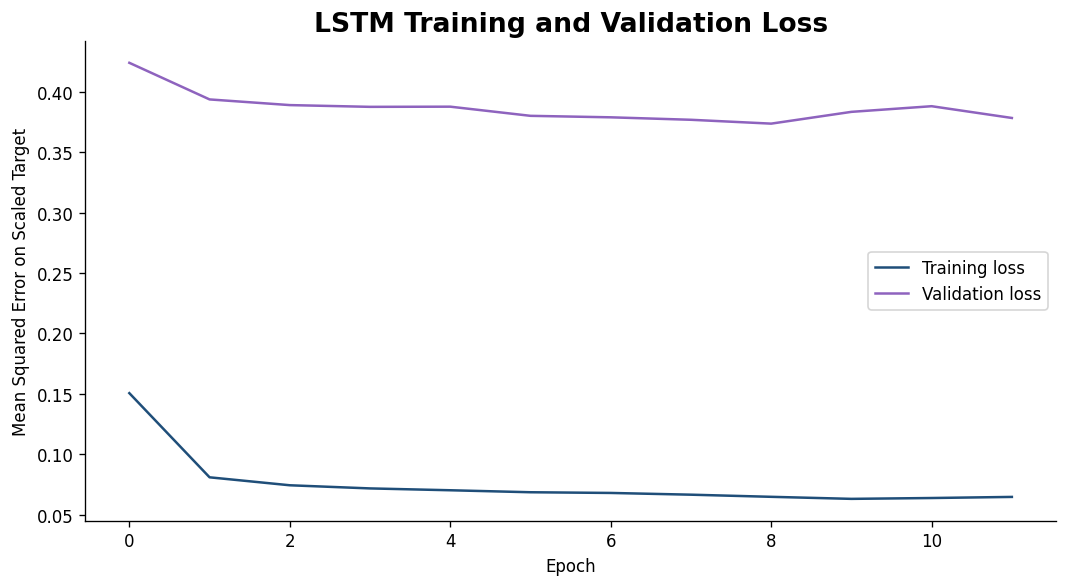

In [7]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.plot(history.history["loss"], label="Training loss", color="#1f4e79")
ax.plot(history.history["val_loss"], label="Validation loss", color="#8e63be")
ax.set_title("LSTM Training and Validation Loss", fontsize=16, weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error on Scaled Target")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
fig.savefig(
    figures_dir / "lstm_training_history.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation Rule

Treat this as a separate next-hour forecasting benchmark. The persistence baseline is the minimum meaningful comparison because it uses the same historical information. Do not compare the LSTM's metrics directly with the tabular validation table unless the tabular models are rebuilt with the same lagged-input forecasting design.